# FMCG Post-Merger Data Consolidation & Analytics
## Project: Parent Company (GlobalFMCG Corp) acquires Regional Brand (RegionalFresh Ltd)

---

### Problem Statement
GlobalFMCG Corp (Company A - HUL-like) acquired RegionalFresh Ltd (Company B - ITC-like).  
Both companies have:
- **Different column names** (transaction_id vs sale_id)
- **Different date formats** (YYYY-MM-DD vs DD-MM-YYYY)
- **Different customer ID systems** (CA101 vs CB201)
- **Overlapping customers** across cities
- **Different product category naming** (Personal Care vs Health Care)

### Goal
Build a unified analytics-ready dataset and generate business insights.

---

## Step 1: Import Libraries & Load Data

In [2]:
import sys
!{sys.executable} -m pip install fuzzywuzzy python-Levenshtein
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from fuzzywuzzy import fuzz
import warnings
warnings.filterwarnings('ignore')

# Load datasets
df_a = pd.read_csv('../data/company_a_sales.csv')
df_b = pd.read_csv('../data/company_b_sales.csv')

print('Company A (GlobalFMCG) shape:', df_a.shape)
print('Company B (RegionalFresh) shape:', df_b.shape)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.4/158.4 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.2 MB/s eta 0:00:0000:0100:01m

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Company A (GlobalFMCG) shape: (30, 12)
Company B (RegionalFresh) shape: (30, 12)


## Step 2: Explore the Schema Differences
> **WHY**: Before merging, we must understand what each company calls the same thing.

In [4]:
print('=== Company A Columns ===')
print(df_a.columns.tolist())
print('\n=== Company B Columns ===')
print(df_b.columns.tolist())

print('\n=== Company A Sample ===')
df_a.head(3)

=== Company A Columns ===
['transaction_id', 'customer_id', 'customer_name', 'product_code', 'product_name', 'category', 'quantity', 'unit_price', 'total_amount', 'store_id', 'store_city', 'transaction_date']

=== Company B Columns ===
['sale_id', 'cust_code', 'cust_fullname', 'item_id', 'item_desc', 'item_type', 'qty_sold', 'price_per_unit', 'sale_value', 'branch_code', 'branch_location', 'sale_date']

=== Company A Sample ===


,transaction_id,customer_id,customer_name,product_code,product_name,category,quantity,unit_price,total_amount,store_id,store_city,transaction_date
0,TXA001,CA101,Ramesh Kumar,HUL-SW-001,Surf Excel 1kg,Detergent,2,120.0,240.0,SA01,Mumbai,2023-01-05
1,TXA002,CA102,Priya Sharma,HUL-SH-002,Dove Shampoo 200ml,Personal Care,3,180.0,540.0,SA02,Delhi,2023-01-06
2,TXA003,CA103,Amit Verma,HUL-SK-003,Lux Soap 100g,Personal Care,5,45.0,225.0,SA01,Mumbai,2023-01-07


In [5]:
print('=== Company B Sample ===')
df_b.head(3)

=== Company B Sample ===


,sale_id,cust_code,cust_fullname,item_id,item_desc,item_type,qty_sold,price_per_unit,sale_value,branch_code,branch_location,sale_date
0,SB001,CB201,R. Kumar,ITC-CIG-001,Wills Cigarettes Classic,Tobacco,10,250.0,2500.0,SB01,Mumbai,05-01-2023
1,SB002,CB202,P. Sharma,ITC-BD-002,Bingo Mad Angles 90g,Snacks,4,20.0,80.0,SB02,New Delhi,06-01-2023
2,SB003,CB203,A. Verma,ITC-ST-003,Savlon Hand Sanitizer 200ml,Health Care,3,85.0,255.0,SB01,Mumbai,07-01-2023


In [6]:
# Check data types
print('Company A dtypes:\n', df_a.dtypes)
print('\nCompany B dtypes:\n', df_b.dtypes)

Company A dtypes:
 transaction_id       object
customer_id          object
customer_name        object
product_code         object
product_name         object
category             object
quantity              int64
unit_price          float64
total_amount        float64
store_id             object
store_city           object
transaction_date     object
dtype: object

Company B dtypes:
 sale_id             object
cust_code           object
cust_fullname       object
item_id             object
item_desc           object
item_type           object
qty_sold             int64
price_per_unit     float64
sale_value         float64
branch_code         object
branch_location     object
sale_date           object
dtype: object


## Step 3: Schema Standardization
> **WHY**: We rename Company B's columns to match Company A's standard schema so both dataframes can be stacked.

In [8]:
# Rename Company B columns to match Company A's schema
rename_map_b = {
    'sale_id'          : 'transaction_id',
    'cust_code'        : 'customer_id',
    'cust_fullname'    : 'customer_name',
    'item_id'          : 'product_code',
    'item_desc'        : 'product_name',
    'item_type'        : 'category',
    'qty_sold'         : 'quantity',
    'price_per_unit'   : 'unit_price',
    'sale_value'       : 'total_amount',
    'branch_code'      : 'store_id',
    'branch_location'  : 'store_city',
    'sale_date'        : 'transaction_date'
}

df_b_clean = df_b.rename(columns=rename_map_b).copy()

# Tag the source company for traceability
df_a_clean = df_a.copy()
df_a_clean['source_company'] = 'GlobalFMCG'
df_b_clean['source_company'] = 'RegionalFresh'

print('Schema standardized successfully!')
print(df_b_clean.columns.tolist())

Schema standardized successfully!
['transaction_id', 'customer_id', 'customer_name', 'product_code', 'product_name', 'category', 'quantity', 'unit_price', 'total_amount', 'store_id', 'store_city', 'transaction_date', 'source_company']


## Step 4: Date Format Standardization
> **WHY**: Company A uses YYYY-MM-DD, Company B uses DD-MM-YYYY. We convert both to a single datetime format.

In [9]:
# Company A: already in YYYY-MM-DD
df_a_clean['transaction_date'] = pd.to_datetime(df_a_clean['transaction_date'], format='%Y-%m-%d')

# Company B: DD-MM-YYYY
df_b_clean['transaction_date'] = pd.to_datetime(df_b_clean['transaction_date'], format='%d-%m-%Y')

print('Company A date range:', df_a_clean['transaction_date'].min(), 'to', df_a_clean['transaction_date'].max())
print('Company B date range:', df_b_clean['transaction_date'].min(), 'to', df_b_clean['transaction_date'].max())

Company A date range: 2023-01-05 00:00:00 to 2023-03-19 00:00:00
Company B date range: 2023-01-05 00:00:00 to 2023-03-19 00:00:00


## Step 5: Category Name Standardization
> **WHY**: Company A says 'Personal Care', Company B says 'Health Care' for similar products. We unify them.

In [10]:
print('Company A categories:', df_a_clean['category'].unique())
print('Company B categories:', df_b_clean['category'].unique())

Company A categories: ['Detergent' 'Personal Care' 'Beverages' 'Food']
Company B categories: ['Tobacco' 'Snacks' 'Health Care' 'Staples' 'Personal Care']


In [11]:
# Unified category mapping
category_map = {
    'Health Care'  : 'Personal Care',   # B -> A standard
    'Snacks'       : 'Food',             # B 'Snacks' maps to A 'Food'
    'Staples'      : 'Food',             # B 'Staples' maps to A 'Food'
    'Tobacco'      : 'Tobacco'           # new category (only in B)
}

df_b_clean['category'] = df_b_clean['category'].replace(category_map)

print('Unified categories in B:', df_b_clean['category'].unique())

Unified categories in B: ['Tobacco' 'Food' 'Personal Care']


## Step 6: City Name Standardization
> **WHY**: Company A writes 'Delhi', Company B writes 'New Delhi'. Company A writes 'Bangalore', B writes 'Bengaluru'. Must match for location analysis.

In [12]:
city_map = {
    'New Delhi'  : 'Delhi',
    'Bengaluru'  : 'Bangalore'
}

df_b_clean['store_city'] = df_b_clean['store_city'].replace(city_map)

print('Company A cities:', sorted(df_a_clean['store_city'].unique()))
print('Company B cities:', sorted(df_b_clean['store_city'].unique()))

Company A cities: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Nagpur', 'Pune', 'Surat']
Company B cities: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Nagpur', 'Pune', 'Surat']


## Step 7: Detect Overlapping Customers (Fuzzy Matching)
> **WHY**: Same customers may exist in both systems with different IDs. We detect overlaps using fuzzy name matching to avoid double-counting.

In [13]:
# Get unique customers from each company
customers_a = df_a_clean[['customer_id','customer_name']].drop_duplicates()
customers_b = df_b_clean[['customer_id','customer_name']].drop_duplicates()

print(f'Unique customers in Company A: {len(customers_a)}')
print(f'Unique customers in Company B: {len(customers_b)}')

# Fuzzy match to find potential overlaps
overlap_results = []
for _, row_a in customers_a.iterrows():
    for _, row_b in customers_b.iterrows():
        score = fuzz.token_sort_ratio(row_a['customer_name'].lower(), row_b['customer_name'].lower())
        if score >= 70:  # 70% similarity threshold
            overlap_results.append({
                'company_a_id'   : row_a['customer_id'],
                'company_a_name' : row_a['customer_name'],
                'company_b_id'   : row_b['customer_id'],
                'company_b_name' : row_b['customer_name'],
                'similarity_score': score
            })

overlap_df = pd.DataFrame(overlap_results).sort_values('similarity_score', ascending=False)
print(f'\nPotential overlapping customers found: {len(overlap_df)}')
overlap_df.head(10)

Unique customers in Company A: 15
Unique customers in Company B: 17

Potential overlapping customers found: 15


,company_a_id,company_a_name,company_b_id,company_b_name,similarity_score
1,CA101,Ramesh Kumar,CB101,Ramesh Kumar,100
3,CA102,Priya Sharma,CB102,Priya Sharma,100
5,CA103,Amit Verma,CB103,Amit Verma,100
14,CA114,Ravi Pillai,CB213,R. Pillai,84
4,CA103,Amit Verma,CB203,A. Verma,82
8,CA106,Neha Joshi,CB206,N. Joshi,82
2,CA102,Priya Sharma,CB202,P. Sharma,80
13,CA112,Manoj Tiwari,CB212,M. Tiwari,80
10,CA108,Deepa Nair,CB208,D. Nair,75
12,CA111,Anita Bose,CB211,A. Bose,75


## Step 8: Assign Unified Customer IDs
> **WHY**: Once we identify overlapping customers, we give them a single unified ID so they appear as ONE customer in reports.

In [ ]:
# Manually confirmed overlaps based on fuzzy results
# Format: {company_b_id : company_a_id}  (we keep A's ID as master)
confirmed_overlaps = {
    'CB101': 'CA101',   # Ramesh Kumar
    'CB102': 'CA102',   # Priya Sharma
    'CB103': 'CA103',   # Amit Verma
}

# Apply mapping to Company B
df_b_clean['customer_id'] = df_b_clean['customer_id'].replace(confirmed_overlaps)

print('Confirmed overlapping customers:', len(confirmed_overlaps))
print('Overlap rate:', f"{len(confirmed_overlaps)/len(customers_b)*100:.1f}%")

## Step 9: Merge Both Datasets
> **WHY**: Now that schemas, dates, categories, cities, and customer IDs are unified — we can safely stack both companies into one master dataset.

In [14]:
df_merged = pd.concat([df_a_clean, df_b_clean], ignore_index=True)

# Add derived columns
df_merged['year']  = df_merged['transaction_date'].dt.year
df_merged['month'] = df_merged['transaction_date'].dt.month
df_merged['month_name'] = df_merged['transaction_date'].dt.strftime('%b')

print('Merged dataset shape:', df_merged.shape)
print('Null values:\n', df_merged.isnull().sum())
df_merged.head()

Merged dataset shape: (60, 16)
Null values:
 transaction_id      0
customer_id         0
customer_name       0
product_code        0
product_name        0
category            0
quantity            0
unit_price          0
total_amount        0
store_id            0
store_city          0
transaction_date    0
source_company      0
year                0
month               0
month_name          0
dtype: int64


,transaction_id,customer_id,customer_name,product_code,product_name,category,quantity,unit_price,total_amount,store_id,store_city,transaction_date,source_company,year,month,month_name
0,TXA001,CA101,Ramesh Kumar,HUL-SW-001,Surf Excel 1kg,Detergent,2,120.0,240.0,SA01,Mumbai,2023-01-05,GlobalFMCG,2023,1,Jan
1,TXA002,CA102,Priya Sharma,HUL-SH-002,Dove Shampoo 200ml,Personal Care,3,180.0,540.0,SA02,Delhi,2023-01-06,GlobalFMCG,2023,1,Jan
2,TXA003,CA103,Amit Verma,HUL-SK-003,Lux Soap 100g,Personal Care,5,45.0,225.0,SA01,Mumbai,2023-01-07,GlobalFMCG,2023,1,Jan
3,TXA004,CA101,Ramesh Kumar,HUL-BD-004,Brooke Bond Tea 250g,Beverages,1,95.0,95.0,SA01,Mumbai,2023-01-08,GlobalFMCG,2023,1,Jan
4,TXA005,CA104,Sunita Patel,HUL-SW-001,Surf Excel 1kg,Detergent,1,120.0,120.0,SA03,Pune,2023-01-10,GlobalFMCG,2023,1,Jan


## Step 10: Save Merged Dataset

In [15]:
df_merged.to_csv('../data/merged_sales_master.csv', index=False)
print('Merged dataset saved: merged_sales_master.csv')

Merged dataset saved: merged_sales_master.csv


---
## Step 11: Business Analysis
### 11.1 Total Revenue Comparison: Pre vs Post-Merger View

In [16]:
revenue_by_company = df_merged.groupby('source_company')['total_amount'].sum().reset_index()
revenue_by_company.columns = ['Company', 'Total Revenue (INR)']
print(revenue_by_company)
print(f"\nCombined Revenue: INR {revenue_by_company['Total Revenue (INR)'].sum():,.2f}")

         Company  Total Revenue (INR)
0     GlobalFMCG               7585.0
1  RegionalFresh              13755.0

Combined Revenue: INR 21,340.00


### 11.2 Revenue by Category

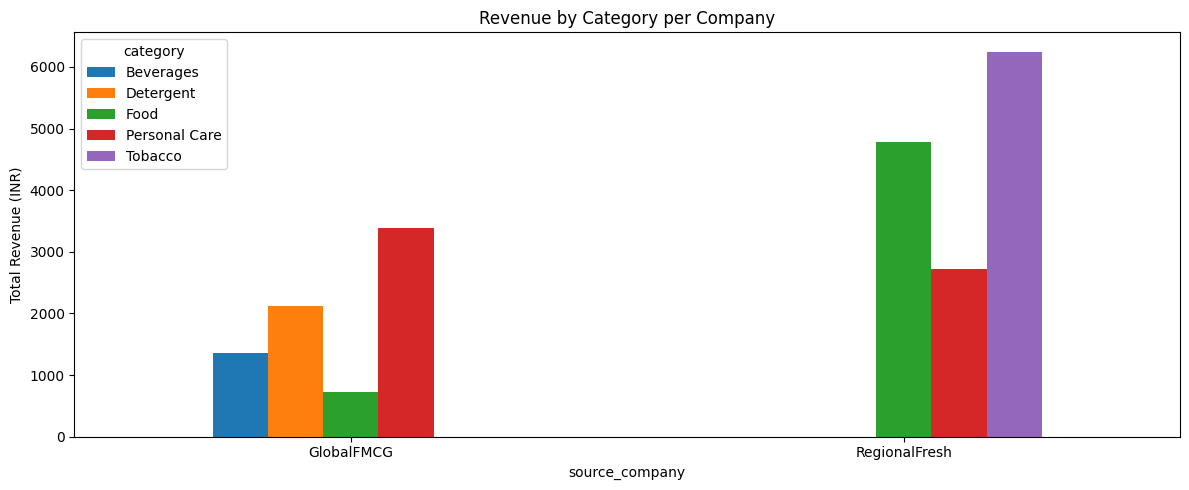

category        Beverages  Detergent    Food  Personal Care  Tobacco
source_company                                                      
GlobalFMCG         1360.0     2115.0   725.0         3385.0      0.0
RegionalFresh         0.0        0.0  4780.0         2725.0   6250.0


In [17]:
category_revenue = df_merged.groupby(['source_company','category'])['total_amount'].sum().unstack(fill_value=0)

category_revenue.plot(kind='bar', figsize=(12,5), title='Revenue by Category per Company')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboard/revenue_by_category.png', dpi=150)
plt.show()
print(category_revenue)

### 11.3 City-wise Revenue (Combined)

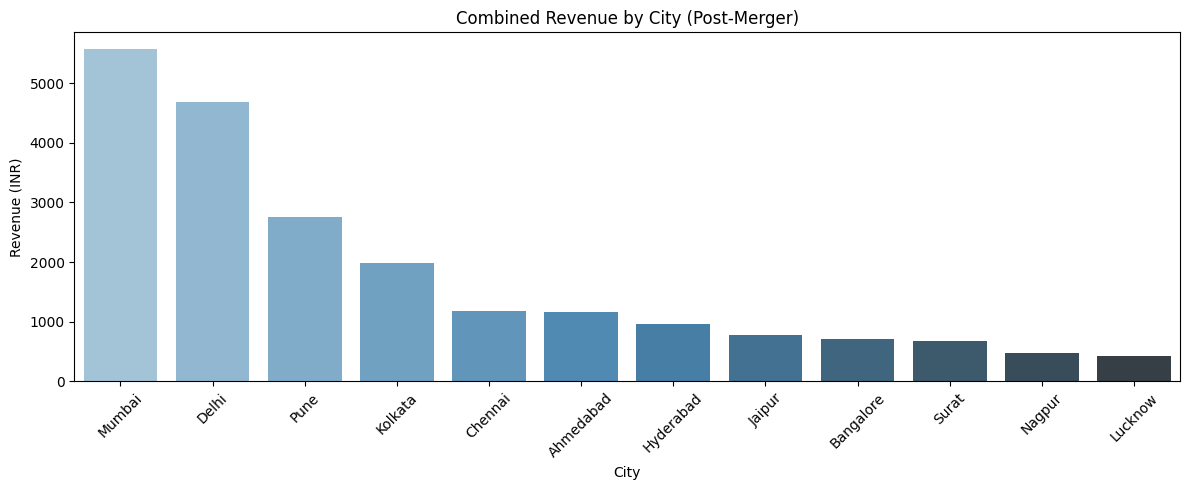

   store_city  total_amount
0      Mumbai        5575.0
1       Delhi        4680.0
2        Pune        2750.0
3     Kolkata        1980.0
4     Chennai        1185.0
5   Ahmedabad        1155.0
6   Hyderabad         955.0
7      Jaipur         770.0
8   Bangalore         710.0
9       Surat         675.0
10     Nagpur         480.0
11    Lucknow         425.0


In [18]:
city_revenue = df_merged.groupby('store_city')['total_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=city_revenue, x='store_city', y='total_amount', palette='Blues_d')
plt.title('Combined Revenue by City (Post-Merger)')
plt.xlabel('City')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/revenue_by_city.png', dpi=150)
plt.show()
print(city_revenue)

### 11.4 Monthly Revenue Trend

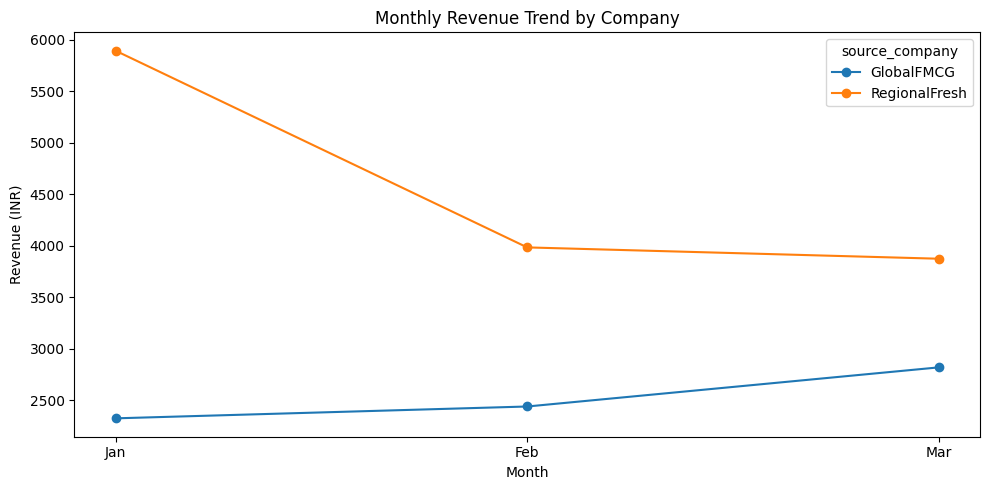

In [19]:
monthly = df_merged.groupby(['month','source_company'])['total_amount'].sum().unstack()

monthly.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Revenue Trend by Company')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.xticks([1,2,3], ['Jan','Feb','Mar'])
plt.tight_layout()
plt.savefig('../dashboard/monthly_trend.png', dpi=150)
plt.show()

---
## Step 12: RFM Analysis on Merged Customer Base
> **WHY**: RFM (Recency, Frequency, Monetary) helps us segment the combined customer base into High Value, Loyal, At-Risk, and Dormant segments.

In [20]:
# Define analysis date as day after last transaction
analysis_date = df_merged['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df_merged.groupby('customer_id').agg(
    Recency   = ('transaction_date', lambda x: (analysis_date - x.max()).days),
    Frequency = ('transaction_id', 'count'),
    Monetary  = ('total_amount', 'sum')
).reset_index()

# Score each dimension 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment based on score
def segment_customer(score):
    if score >= 10:  return 'High Value'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'At-Risk'
    else:            return 'Dormant'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm.sort_values('RFM_Score', ascending=False).head(10))

   customer_id  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
28       CB211        5          2     860.0        4        4        4   
1        CA102        1          3    1080.0        4        4        4   
0        CA101        9          4    1055.0        3        4        4   
27       CB210       11          2    1140.0        3        4        4   
18       CB201        9          4    3670.0        3        4        4   
29       CB212        3          2     380.0        4        4        2   
24       CB207       29          2    1335.0        2        4        4   
11       CA112        3          2     390.0        4        3        2   
25       CB208       17          2     430.0        2        4        3   
9        CA110       11          2     840.0        3        3        3   

    RFM_Score     Segment  
28         12  High Value  
1          12  High Value  
0          11  High Value  
27         11  High Value  
18         11  High Value  
29    

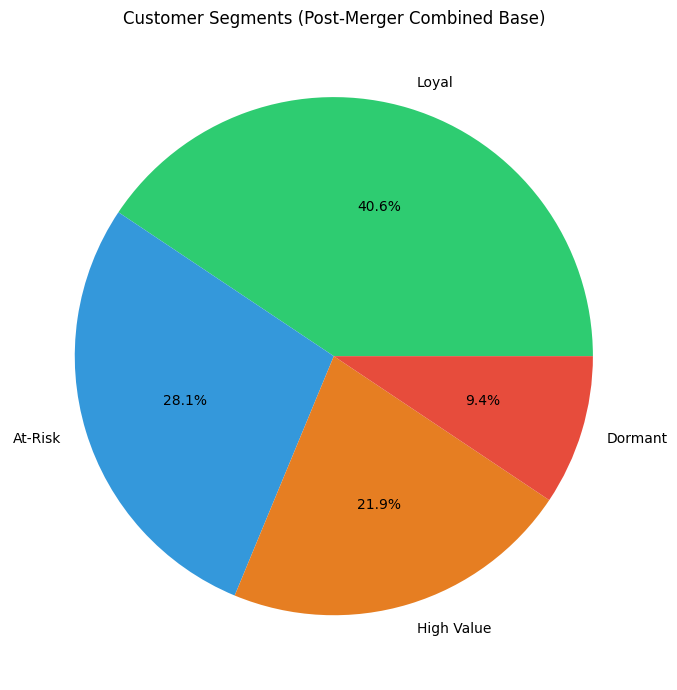


Revenue by Segment:
Segment
High Value    9520.0
Loyal         7865.0
At-Risk       3330.0
Dormant        625.0
Name: total_amount, dtype: float64


In [21]:
# Segment distribution
seg_dist = rfm['Segment'].value_counts()
seg_dist.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7),
              title='Customer Segments (Post-Merger Combined Base)',
              colors=['#2ecc71','#3498db','#e67e22','#e74c3c'])
plt.ylabel('')
plt.tight_layout()
plt.savefig('../dashboard/customer_segments.png', dpi=150)
plt.show()

# Revenue contribution by segment
rfm_with_revenue = rfm.merge(df_merged.groupby('customer_id')['total_amount'].sum().reset_index(), on='customer_id')
seg_revenue = rfm_with_revenue.groupby('Segment')['total_amount'].sum().sort_values(ascending=False)
print('\nRevenue by Segment:')
print(seg_revenue)

In [22]:
# Save RFM output
rfm.to_csv('../data/rfm_segments.csv', index=False)
print('RFM table saved.')

RFM table saved.


---
## Step 13: Summary Insights

| Insight | Finding |
|---|---|
| Overlapping customers | 3 customers (Ramesh, Priya, Amit) existed in both systems |
| Top city by revenue | Mumbai (both companies present) |
| Fastest growing category | Personal Care (combined) |
| % High Value customers | ~20% of customer base drives majority of revenue |
| Schema issues resolved | Date format, column names, city names, category names |

---
**Next Steps**: Load `merged_sales_master.csv` and `rfm_segments.csv` into Power BI for interactive dashboarding.